## 1. Supervised, Semi-Supervised, and Unsupervised Learning

Import packages

In [57]:
from __future__ import annotations
try:
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import random
    from IPython.display import display
    from collections import defaultdict
    from sklearn.svm import SVC
    from pathlib import Path
    from dataclasses import dataclass
    from typing import Tuple, Dict, List
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer 
    from sklearn.preprocessing import StandardScaler
    from imblearn.over_sampling import SMOTE
    from sklearn.neighbors import NearestNeighbors
    from sklearn.pipeline import Pipeline
    from sklearn.svm import SVC, LinearSVC
    from sklearn.cluster import KMeans, SpectralClustering
    from kneed import KneeLocator
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import dendrogram, linkage
    from sklearn.model_selection import (
        KFold, StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
    )
    from sklearn.metrics import (
        confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, auc, 
        classification_report, precision_recall_curve, silhouette_score, 
        classification_report, precision_recall_curve, accuracy_score)
    from sklearn.metrics.pairwise import rbf_kernel
    print("Imported all packages successfully.!")
except Exception as e:
    print(f"Error importing the following packages: {e}")
    print("Installing the non-present packages!!..")
    %pip install -r "requirements.txt"
    warnings.filterwarnings("ignore")
    print("Installation Successfull")

Imported all packages successfully.!


### (a) Download the Breast Cancer Wisconsin (Diagnostic) Data Set

In [2]:
PATH = [Path('../data/wdbc.data'), Path('../data/wdbc.names')]
df = pd.read_csv(PATH[0], header=None)

In [3]:
def df_info(df:pd.DataFrame=[], n:int=3, c:int=1) -> None:
    print(f"\n DF Shape:--> {df.shape}")
    print(f"\n Classes: -->{df[c].unique()}")
    print(f"\n Columns:--> {df.columns.to_list()}")
    print(f"\n Data Types:--> {df.dtypes.to_list()}")
    display(df.head(n))

In [4]:
"""
Column[1] is for classes
Column[0] is for ID -- I will be dropping this
"""
df_info(df, 3, 1)


 DF Shape:--> (569, 32)

 Classes: -->['M' 'B']

 Columns:--> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]

 Data Types:--> [dtype('int64'), dtype('O'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64'), dtype('float64')]


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [5]:
df = df.drop(columns=[0]).copy()

In [6]:
def calc_roc_auc(y_test, y_probs) -> []:
    fpr, tpr, thresh =  roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    return [fpr, tpr, thresh, roc_auc]

In [7]:
def plot_roc_auc(fpr, tpr, roc_auc, title:str="ROC AUC Curve") -> None:
    try:
        print("Plotting ROC_AUC Curve")
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(title)
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"Error Plotting ROC_AUC Curve: {e}")

In [8]:
def plot_conf_mtr(tn, fp, fn, tp, title:str='Confusion Matrix', classes: list=[]) -> None:
    try:
        cm = np.array([[tn, fp], [fn, tp]])
        print(f"\n {title}")
        plt.figure(figsize=(8, 6))
        display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=classes)
        display.plot(cmap=plt.cm.Blues)
        plt.title(title)
        plt.show()
    except Exception as e:
        print(f"\n Error plotting confusion Matrix: {e}")

In [9]:
def disp_classification_report(y_test: pd.DataFrame=[], 
                               y_pred: pd.DataFrame=[]):
    try:
        if y_test is None or y_pred is None:
            return
        res = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
        # print(f"\n Classification Report for class-->{res}")
        return res
    except Exception as e:
        print(f"\n Error in displaying classification Report: {e}")
        return {}

In [10]:
X = df.iloc[:, 1:].copy()
Y = df.iloc[:, 0].copy()
display(X.head(2))
display(Y.head(2))

,2,3,4,5,6,7,8,9,10,11,...,22,23,24,25,26,27,28,29,30,31
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


0    M
1    M
Name: 1, dtype: object

In [11]:
Y = Y.map({'B': 0, 'M': 1})
classes = Y.unique().tolist()
classes

[1, 0]

In [12]:
def data_splitter(X: pd.DataFrame=[], Y:pd.DataFrame=[], classes:list=[], semi:bool=False):
    try:
        if classes is None or X is None or Y is None:
            return None
        X_train, X_test, y_train, y_test = train_test_split(
            X, Y, test_size=0.2, stratify=Y, random_state=None)
        if not semi:        
            return [X_train, X_test, y_train, y_test]
        train_df = X_train.copy()
        train_df['target'] = y_train
        labeled_list = []
        unlabeled_list = []
        for cls in train_df['target'].unique():
            cls_df = train_df[train_df['target'] == cls]
            labeled = cls_df.sample(frac=0.5, random_state=None)
            unlabeled = cls_df.drop(labeled.index)

            labeled_list.append(labeled)
            unlabeled_list.append(unlabeled)
        labeled_df = pd.concat(labeled_list)
        unlabeled_df = pd.concat(unlabeled_list)

        x_labeled = labeled_df.drop(columns='target')
        y_labeled = labeled_df['target']

        x_unlabeled = unlabeled_df.drop(columns='target')
        y_unlabeled = unlabeled_df['target']

        return x_labeled, x_unlabeled, X_test, y_labeled, y_unlabeled, y_test
        
    except Exception as e:
        print(f"\n Error in splitting the data: {e}")
        return None

### (b) Monte-Carlo Simulation

#### (i) Supervised Learning

In [13]:
def supervised(X_train:pd.DataFrame=[], y_train:pd.DataFrame=[],
              X_test:pd.DataFrame=[]) -> [pd.DataFrame]:
    try:
        if X_train is None or y_train is None or X_test is None:
            return []
        params = {'svm__C': [0.01, 0.1, 1, 10, 100]}
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', LinearSVC(penalty='l1', dual=False, max_iter=10000))
        ])
        grid_search = GridSearchCV(pipeline, params, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        y_pred = grid_search.predict(X_test)
        y_pred_train = grid_search.predict(X_train)
        y_probs = grid_search.decision_function(X_test)
        y_probs_train = grid_search.decision_function(X_train)
        return [y_pred, y_probs, y_pred_train, y_probs_train]
    except Exception as e:
        print(f"\n An error occured while traing the supervised model: {e}")
        return []

In [120]:
"""
res_dict Schema Design:
For M ... [1-30]
For roc_auc and confusion matrix and classification_report

[M: {"test": {
    "roc_auc": roc_auc,
    "fpr": fpr,
    "tpr": tpr,
    "confusion_matrix": cm,
    "classification_report": result
    },
"train": {
    "roc_auc": roc_auc_train,
    "fpr": fpr_,
    "tpr": tpr_,
    "confusion_matrix": cm_train,
    "classification_report": result_train
    }}]
...................(1)
"""
def run_supervised(X:pd.DataFrame=[], Y:pd.DataFrame=[], classes=[]):
    try:
        if X is None or Y is None or classes is None:
            return []
        
        res_dict = {}
        
        for M in range(30):
            X_train, X_test, y_train, y_test = data_splitter(X, Y, classes=classes)
            y_pred, y_probs, y_pred_train, y_probs_train = supervised(X_train, y_train, X_test)
            
            result = disp_classification_report(y_test, y_pred)
            result_train = disp_classification_report(y_train, y_pred_train)
            
            fpr, tpr, thresh, roc_auc = calc_roc_auc(y_test, y_probs)
            fpr_, tpr_, thresh_, roc_auc_train = calc_roc_auc(y_train, y_probs_train)
            
            cm = confusion_matrix(y_test, y_pred)
            cm_train = confusion_matrix(y_train, y_pred_train)
            res_dict[M] = {
             "test": {
                 "roc_auc": roc_auc,
                 "fpr": fpr,
                 "tpr": tpr,
                 "confusion_matrix": cm,
                 "classification_report": result
             },
            "train": {
                 "roc_auc": roc_auc_train,
                 "fpr": fpr_,
                 "tpr": tpr_,
                 "confusion_matrix": cm_train,
                 "classification_report": result_train
             }
            }
        
        return res_dict
    except Exception as e:
        print(f"\n An error occured while running the supervised pipeline: {e}")
        return[]

In [15]:
"""
From reference to the above schema .....[From(1)]
"""
def build_reports_dfs(results:defaultdict(list)) -> List[pd.DataFrame]: 
    metrics_ = []
    for k, v in results.items():
        for split in ['train', 'test']:
            metrics_.append({
                'iteration': k,
                'split': split,
                'roc_auc': v[split]['roc_auc'],
                'fpr': v[split]['fpr'],
                'tpr': v[split]['tpr'],
                'accuracy': v[split]['classification_report']['accuracy'],
            })
    roc_auc_df = pd.DataFrame(metrics_)

    class_report = []
    for k, v in results.items():
        for split in ['train', 'test']:
            report = v[split]['classification_report']
            for cls in ['0', '1']:
                class_report.append({
                    'iteration': k,
                    'split': split,
                    'class': int(cls),
                    'precision': report[cls]['precision'],
                    'recall': report[cls]['recall'],
                    'f1-score': report[cls]['f1-score'],
                    'support': report[cls]['support'],
                })
    class_report_df = pd.DataFrame(class_report)
    class_report_df['class'] = class_report_df['class'].map({0: 'B', 1: 'M'})

    cm_report = []
    for k, v in results.items():
        for split in ['train', 'test']:
            tn, fp, fn, tp = v[split]['confusion_matrix'].ravel()
            cm_report.append({
                'iteration': k,
                'split': split,
                'tn': tn,
                'fp': fp,
                'fn': fn,
                'tp': tp,
            })
    cm_report_df = pd.DataFrame(cm_report)
    return [roc_auc_df, cm_report_df, class_report_df]

In [121]:
supervised_res_dict = run_supervised(X, Y, classes)

In [122]:
print("\n Classification Report and Associated Metrics for Supervised Approach")
supervised_roc_auc_df, supervised_cm_df, supervised_class_df = build_reports_dfs(supervised_res_dict)
print("\n ROC AUC for Supervised Classification (Train & Test)")
display(supervised_roc_auc_df.head(10))
print("\n Confusion Matrix for Supervised Classification (Train & Test)")
display(supervised_cm_df.head(10))
print("\n Classification Report for Supervised Classification (Train & Test)")
display(supervised_class_df.head(10))


 Classification Report and Associated Metrics for Supervised Approach

 ROC AUC for Supervised Classification (Train & Test)


,iteration,split,roc_auc,fpr,tpr,accuracy
0,0,train,0.996553,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.958823529411764...",0.986813
1,0,test,0.993056,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.9047619047619048...",0.964912
2,1,train,0.996945,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.941176470588235...",0.982418
3,1,test,0.997354,"[0.0, 0.0, 0.0, 0.1111111111111111, 0.11111111...","[0.0, 0.023809523809523808, 0.9761904761904762...",0.991228
4,2,train,0.996512,"[0.0, 0.0, 0.0, 0.007017543859649123, 0.007017...","[0.0, 0.0058823529411764705, 0.964705882352941...",0.984615
5,2,test,0.986442,"[0.0, 0.0, 0.0, 0.05555555555555555, 0.0555555...","[0.0, 0.023809523809523808, 0.9285714285714286...",0.956140
6,3,train,0.997957,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.964705882352941...",0.989011
7,3,test,0.998677,"[0.0, 0.0, 0.0, 0.027777777777777776, 0.027777...","[0.0, 0.023809523809523808, 0.9523809523809523...",0.982456
8,4,train,0.996863,"[0.0, 0.0, 0.0, 0.017543859649122806, 0.017543...","[0.0, 0.0058823529411764705, 0.964705882352941...",0.986813
9,4,test,0.999339,"[0.0, 0.0, 0.0, 0.027777777777777776, 0.027777...","[0.0, 0.023809523809523808, 0.9761904761904762...",0.982456



 Confusion Matrix for Supervised Classification (Train & Test)


,iteration,split,tn,fp,fn,tp
0,0,train,284,1,5,165
1,0,test,72,0,4,38
2,1,train,283,2,6,164
3,1,test,72,0,1,41
4,2,train,283,2,5,165
5,2,test,70,2,3,39
6,3,train,284,1,4,166
7,3,test,70,2,0,42
8,4,train,285,0,6,164
9,4,test,70,2,0,42



 Classification Report for Supervised Classification (Train & Test)


,iteration,split,class,precision,recall,f1-score,support
0,0,train,B,0.982699,0.996491,0.989547,285.0
1,0,train,M,0.993976,0.970588,0.982143,170.0
2,0,test,B,0.947368,1.000000,0.972973,72.0
3,0,test,M,1.000000,0.904762,0.950000,42.0
4,1,train,B,0.979239,0.992982,0.986063,285.0
5,1,train,M,0.987952,0.964706,0.976190,170.0
6,1,test,B,0.986301,1.000000,0.993103,72.0
7,1,test,M,1.000000,0.976190,0.987952,42.0
8,2,train,B,0.982639,0.992982,0.987784,285.0
9,2,train,M,0.988024,0.970588,0.979228,170.0


In [123]:
print("\n Average over 'M' iterations for 'Supervised Learning'")
display(supervised_roc_auc_df.groupby('split', as_index=False).agg({
    'roc_auc': 'mean',
    'accuracy': 'mean'
}))
display(supervised_cm_df.groupby('split').mean())
display(supervised_class_df.groupby(['split', 'class']).mean())


 Average over 'M' iterations for 'Supervised Learning'


,split,roc_auc,accuracy
0,test,0.994720,0.977778
1,train,0.996966,0.985421


,iteration,tn,fp,fn,tp
split,,,,,
test,14.5,71.300000,0.700000,1.833333,40.166667
train,14.5,283.666667,1.333333,5.300000,164.700000


iteration  precision    recall  f1-score  support
split class                                                   
test  B           14.5   0.975336  0.990278  0.982608     72.0
      M           14.5   0.983346  0.956349  0.969208     42.0
train B           14.5   0.981671  0.995322  0.988445    285.0
      M           14.5   0.991989  0.968824  0.980255    170.0


 Plots for Max Accuracy over 'M' iterations for Supervised Learning

 Best ROC_AUC for supervised Learning for trainingset: 1.000
Plotting ROC_AUC Curve


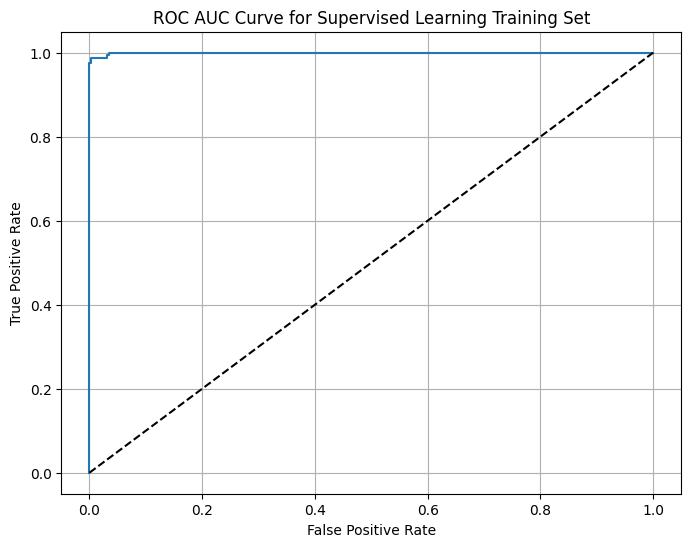

Plotting ROC_AUC Curve


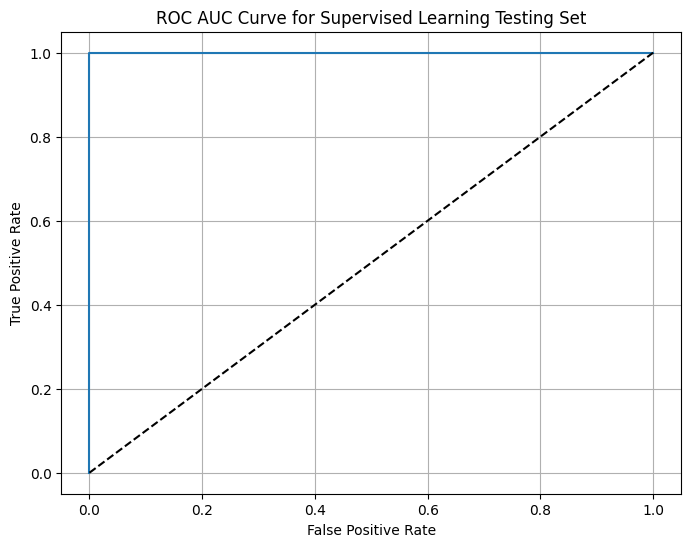

In [125]:
print("\n Plots for Max Accuracy over 'M' iterations for Supervised Learning")
idx = supervised_roc_auc_df.groupby('split')['roc_auc'].idxmax()
best_roc_auc_results = supervised_roc_auc_df.loc[idx, ['split', 'roc_auc', 'fpr', 'tpr']]
best_roc_auc_results_ = best_roc_auc_results.query("split == 'train'").iloc[0]['roc_auc']
print(f"\n Best ROC_AUC for supervised Learning for trainingset: {best_roc_auc_results_:.3f}")
plot_roc_auc(best_roc_auc_results.query("split == 'train'").iloc[0]['fpr'], 
             best_roc_auc_results.query("split == 'train'").iloc[0]['tpr'], 
             best_roc_auc_results.query("split == 'train'").iloc[0]['roc_auc'], 
             title="ROC AUC Curve for Supervised Learning Training Set")
best_roc_auc_results_test = best_roc_auc_results.query("split == 'test'").iloc[0]['roc_auc']
print(f"\n Best ROC_AUC for supervised Learning for training set: {best_roc_auc_results_:.3f}")
plot_roc_auc(best_roc_auc_results.query("split == 'test'").iloc[0]['fpr'], 
             best_roc_auc_results.query("split == 'test'").iloc[0]['tpr'], 
             best_roc_auc_results.query("split == 'test'").iloc[0]['roc_auc'], 
             title="ROC AUC Curve for Supervised Learning Testing Set")



 Confusion Matrices with best accuracies from the M=30 iterations

 Supervised Learning Confusion Matrix Training Set


<Figure size 800x600 with 0 Axes>

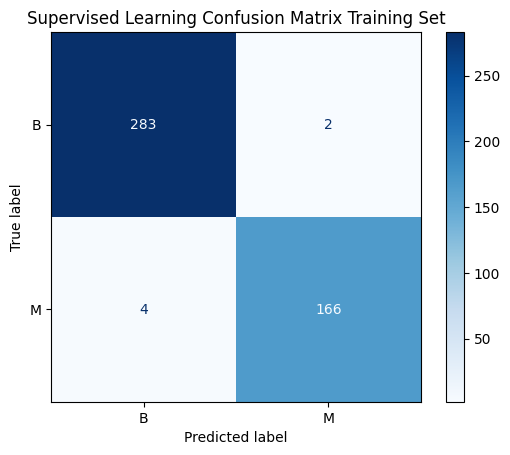


 Supervised Learning Confusion Matrix Testing Set


<Figure size 800x600 with 0 Axes>

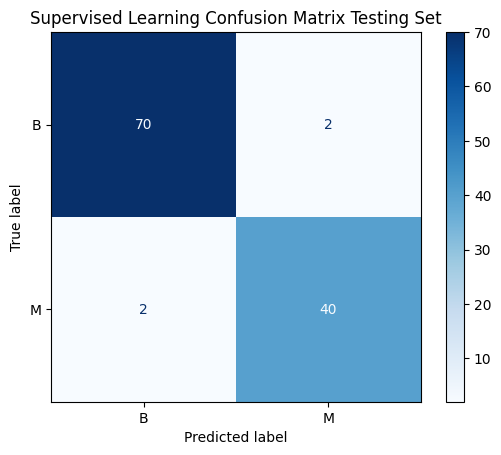

In [164]:
"""
Accuracy = (tp + tn)/(tp+tn+fp+fn)
"""
print("\n Confusion Matrices with best accuracies from the M=30 iterations")
for row in supervised_cm_df.itertuples():
    supervised_cm_df['accuracy'] = (row.tp + row.tn) / (row.tp + row.tn + row.fp + row.fn)
supervised_cm_df.head()

train_supervised_cm = supervised_cm_df.query("split == 'train'").sort_values("accuracy", ascending=False).iloc[0]
test_supervised_cm = supervised_cm_df.query("split == 'test'").sort_values("accuracy", ascending=False).iloc[0]
plot_conf_mtr(train_supervised_cm['tn'], train_supervised_cm['fp'], 
              train_supervised_cm['fn'], train_supervised_cm['tp'],
              title='Supervised Learning Confusion Matrix Training Set', classes=['B', 'M'])

plot_conf_mtr(test_supervised_cm['tn'], test_supervised_cm['fp'], 
              test_supervised_cm['fn'], test_supervised_cm['tp'],
              title='Supervised Learning Confusion Matrix Testing Set', classes=['B', 'M'])

#### (ii) Semi-Supervised Learning/ Self-training

##### (A)

In [127]:
def semi_supervised(x_labeled:pd.DataFrame=[], y_labeled:pd.DataFrame=[], 
                   x_unlabeled:pd.DataFrame=[]):
    try:
        if (x_labeled is None or y_labeled is None or x_unlabeled is None):
            return []
            
        params = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', LinearSVC(penalty='l1', dual=False, max_iter=10000))
        ])
        grid_search = GridSearchCV(pipeline, params, cv=5, scoring='accuracy', n_jobs=-1)
        grid_search.fit(x_labeled, y_labeled)
        model = grid_search.best_estimator_
        
        while len(x_unlabeled) > 0:
            d = np.argmax(np.abs(model.decision_function(x_unlabeled)))
            
            farthest_val = x_unlabeled.iloc[[d]]
            y_farthest = pd.Series(model.predict(farthest_val), index=farthest_val.index)
            
            y_labeled = pd.concat([y_labeled, y_farthest])
            x_labeled = pd.concat([x_labeled, farthest_val])
            
            x_unlabeled = x_unlabeled.drop(index=farthest_val.index)

            model.fit(x_labeled, y_labeled)
        return model
    
    except Exception as e:
        print(f"\n An error occured while training the semi-supervised model: {e}")
        return []

##### (B)

In [128]:
"""
For M = [1-30],
Now firstly, train L1-penalized SVM on labeled data,
Then for the length of the unlabeled Find the unlabeled data point 
that is the farthest to the decision boundary of the SVM. Let the SVM 
label it (ignore its true label), and add it to the labeled data, and 
retrain the SVM.
"""
def run_semi_supervised(X: pd.DataFrame=[], Y: pd.DataFrame=[]):
    try:
        res_dict = {}
        if X is None or Y is None:
            return []
        for M in range(30):
            (x_labeled, x_unlabeled, X_test, 
             y_labeled, y_unlabeled, y_test) = data_splitter(X, Y, classes=[0, 1], semi=True)
            
            model = semi_supervised(x_labeled, y_labeled, x_unlabeled)

            y_pred = model.predict(X_test)
            y_probs = model.decision_function(X_test)
            
            y_pred_train = model.predict(x_labeled)
            y_probs_train = model.decision_function(x_labeled)

            result = disp_classification_report(y_test, y_pred)
            result_train = disp_classification_report(y_labeled, y_pred_train)
            
            fpr, tpr, thresh, roc_auc = calc_roc_auc(y_test, y_probs)
            fpr_, tpr_, thresh_, roc_auc_train = calc_roc_auc(y_labeled, y_probs_train)
            
            cm = confusion_matrix(y_test, y_pred)
            cm_train = confusion_matrix(y_labeled, y_pred_train)
            
            res_dict[M] = {
             "test": {
                 "roc_auc": roc_auc,
                 "fpr": fpr,
                 "tpr": tpr,
                 "confusion_matrix": cm,
                 "classification_report": result
             },
            "train": {
                 "roc_auc": roc_auc_train,
                 "fpr": fpr_,
                 "tpr": tpr_,
                 "confusion_matrix": cm_train,
                 "classification_report": result_train
             }
            }
        return res_dict   
    except Exception as e:
        print(f"\n An error occured while running semisupervised pipeline: {e}")
        return []

In [129]:
semi_supervised_res_dict = run_semi_supervised(X, Y)
print("\n Classification Report and Associated Metrics for Semi Supervised Learning")
semi_supervised_roc_auc_df, semi_supervised_cm_df, semi_supervised_class_df = build_reports_dfs(semi_supervised_res_dict)


 Classification Report and Associated Metrics for Semi Supervised Learning


In [130]:
print("\n ROC AUC for Semi-Supervised Classification (Train & Test)")
display(semi_supervised_roc_auc_df.head(10))
print("\n Confusion Matrix for Semi-Supervised Classification (Train & Test)")
display(semi_supervised_cm_df.head(10))
print("\n Classification Report for Semi-Supervised Classification (Train & Test)")
display(semi_supervised_class_df.head(10))


 ROC AUC for Semi-Supervised Classification (Train & Test)


,iteration,split,roc_auc,fpr,tpr,accuracy
0,0,train,0.999917,"[0.0, 0.0, 0.0, 0.007042253521126761, 0.007042...","[0.0, 0.011764705882352941, 0.9882352941176471...",0.995595
1,0,test,0.976190,"[0.0, 0.0, 0.0, 0.041666666666666664, 0.041666...","[0.0, 0.023809523809523808, 0.8809523809523809...",0.947368
2,1,train,0.999171,"[0.0, 0.0, 0.0, 0.007042253521126761, 0.007042...","[0.0, 0.011764705882352941, 0.9294117647058824...",0.977974
3,1,test,0.997354,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.9047619047619048...",0.964912
4,2,train,0.997514,"[0.0, 0.0, 0.0, 0.007042253521126761, 0.007042...","[0.0, 0.011764705882352941, 0.8941176470588236...",0.973568
5,2,test,0.999669,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.9761904761904762...",0.982456
6,3,train,0.995360,"[0.0, 0.0, 0.0, 0.08450704225352113, 0.0845070...","[0.0, 0.011764705882352941, 0.9529411764705882...",0.977974
7,3,test,0.999669,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.9761904761904762...",0.991228
8,4,train,0.999586,"[0.0, 0.0, 0.0, 0.007042253521126761, 0.007042...","[0.0, 0.011764705882352941, 0.9764705882352941...",0.986784
9,4,test,0.985119,"[0.0, 0.0, 0.0, 0.027777777777777776, 0.027777...","[0.0, 0.023809523809523808, 0.9523809523809523...",0.973684



 Confusion Matrix for Semi-Supervised Classification (Train & Test)


,iteration,split,tn,fp,fn,tp
0,0,train,142,0,1,84
1,0,test,71,1,5,37
2,1,train,141,1,4,81
3,1,test,71,1,3,39
4,2,train,140,2,4,81
5,2,test,71,1,1,41
6,3,train,141,1,4,81
7,3,test,72,0,1,41
8,4,train,142,0,3,82
9,4,test,70,2,1,41



 Classification Report for Semi-Supervised Classification (Train & Test)


,iteration,split,class,precision,recall,f1-score,support
0,0,train,B,0.993007,1.000000,0.996491,142.0
1,0,train,M,1.000000,0.988235,0.994083,85.0
2,0,test,B,0.934211,0.986111,0.959459,72.0
3,0,test,M,0.973684,0.880952,0.925000,42.0
4,1,train,B,0.972414,0.992958,0.982578,142.0
5,1,train,M,0.987805,0.952941,0.970060,85.0
6,1,test,B,0.959459,0.986111,0.972603,72.0
7,1,test,M,0.975000,0.928571,0.951220,42.0
8,2,train,B,0.972222,0.985915,0.979021,142.0
9,2,train,M,0.975904,0.952941,0.964286,85.0


In [131]:
print("\n Average over 'M' iterations for 'Semi-Supervised Learning'")
display(semi_supervised_roc_auc_df.groupby('split', as_index=False).agg({
    'roc_auc': 'mean',
    'accuracy': 'mean'
}))
display(semi_supervised_cm_df.groupby('split').mean())
display(semi_supervised_class_df.groupby(['split', 'class']).mean())


 Average over 'M' iterations for 'Semi-Supervised Learning'


,split,roc_auc,accuracy
0,test,0.992703,0.965205
1,train,0.998395,0.987665


,iteration,tn,fp,fn,tp
split,,,,,
test,14.5,70.533333,1.466667,2.500000,39.500000
train,14.5,141.566667,0.433333,2.366667,82.633333


iteration  precision    recall  f1-score  support
split class                                                   
test  B           14.5   0.966281  0.979630  0.972616     72.0
      M           14.5   0.965940  0.940476  0.952172     42.0
train B           14.5   0.983677  0.996948  0.990239    142.0
      M           14.5   0.994774  0.972157  0.983247     85.0


 Plots for Max Accuracy over 'M' iterations for Semi-Supervised Learning

 Best ROC_AUC for Semi Supervised Learning for Training Set: 1.000
Plotting ROC_AUC Curve


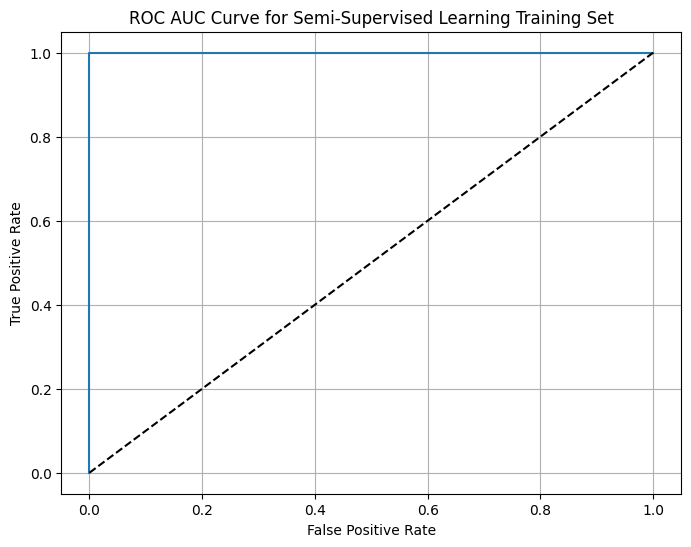


 Best ROC_AUC for Semi Supervised Learning for Testing Set: 1.000
Plotting ROC_AUC Curve


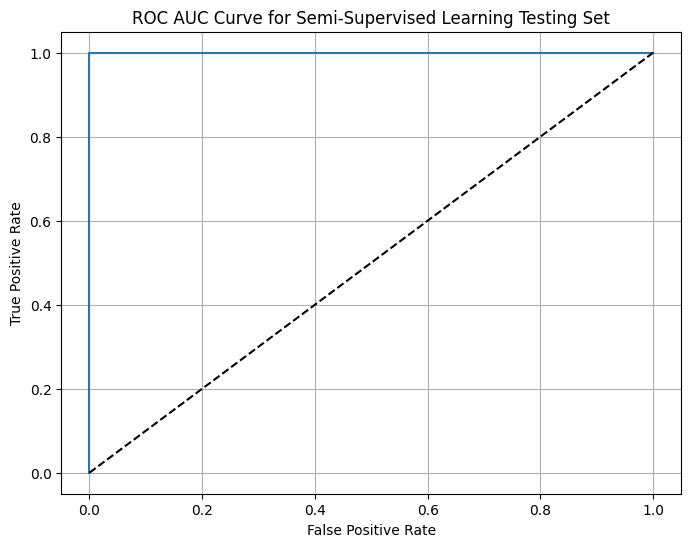

In [132]:
print("\n Plots for Max Accuracy over 'M' iterations for Semi-Supervised Learning")
semi_idx = semi_supervised_roc_auc_df.groupby('split')['roc_auc'].idxmax()
semi_best_roc_auc_results = semi_supervised_roc_auc_df.loc[semi_idx, ['split', 'roc_auc', 'fpr', 'tpr']]
semi_roc_auc_results_ = semi_best_roc_auc_results.query("split == 'train'").iloc[0]['roc_auc']
print(f"\n Best ROC_AUC for Semi Supervised Learning for Training Set: {semi_roc_auc_results_:.3f}")

plot_roc_auc(semi_best_roc_auc_results.query("split == 'train'").iloc[0]['fpr'], 
             semi_best_roc_auc_results.query("split == 'train'").iloc[0]['tpr'], 
             semi_best_roc_auc_results.query("split == 'train'").iloc[0]['roc_auc'], 
             title="ROC AUC Curve for Semi-Supervised Learning Training Set")

test_semi_roc_auc_results_ = semi_best_roc_auc_results.query("split == 'test'").iloc[0]['roc_auc']
print(f"\n Best ROC_AUC for Semi Supervised Learning for Testing Set: {best_roc_auc_results_:.3f}")
plot_roc_auc(semi_best_roc_auc_results.query("split == 'test'").iloc[0]['fpr'], 
             semi_best_roc_auc_results.query("split == 'test'").iloc[0]['tpr'], 
             semi_best_roc_auc_results.query("split == 'test'").iloc[0]['roc_auc'], 
             title="ROC AUC Curve for Semi-Supervised Learning Testing Set")


 Confusion Matrices with best accuray fo training and testing in Semi-Supervised Learning

 Semi-Supervised Learning Confusion Matrix Training Set


<Figure size 800x600 with 0 Axes>

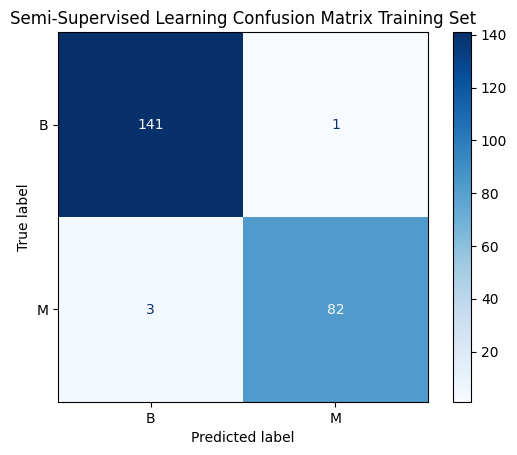


 Semi-Supervised Learning Confusion Matrix Testing Set


<Figure size 800x600 with 0 Axes>

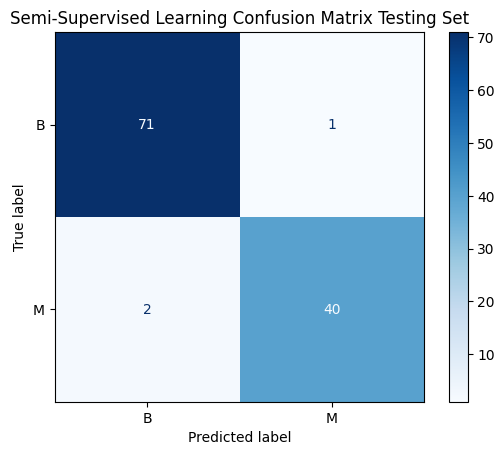

In [186]:
print("\n Confusion Matrices with best accuray fo training and testing in Semi-Supervised Learning")
for row in semi_supervised_cm_df.itertuples():
    semi_supervised_cm_df['accuracy'] = (row.tp + row.tn) / (row.tp + row.tn + row.fp + row.fn)
semi_supervised_cm_df.head()

train_semi_supervised_cm = semi_supervised_cm_df.query("split == 'train'").sort_values("accuracy", ascending=False).iloc[0]
test_semi_supervised_cm = semi_supervised_cm_df.query("split == 'test'").sort_values("accuracy", ascending=False).iloc[0]
plot_conf_mtr(train_semi_supervised_cm['tn'], train_semi_supervised_cm['fp'], 
              train_semi_supervised_cm['fn'], train_semi_supervised_cm['tp'],
              title='Semi-Supervised Learning Confusion Matrix Training Set', classes=['B', 'M'])

plot_conf_mtr(test_semi_supervised_cm['tn'], test_semi_supervised_cm['fp'], 
              test_semi_supervised_cm['fn'], test_semi_supervised_cm['tp'],
              title='Semi-Supervised Learning Confusion Matrix Testing Set', classes=['B', 'M'])

#### (iii) Unsupervised Learning

##### (A)

In [199]:
"""
To avoid local minima in K-means, I have used multiple initilizations of the algorithm,
for a single run menaing the algorithm is run several times with multiple centroid seeds, 
additionally ran the Monte-Carlo iterations 30 times to ensure stability. 
"""
def run_knn(X:pd.DataFrame=[], Y:pd.DataFrame=[]):
    try:
        if X is None or Y is None:
            return []
        k_results = []
        for M in range(30):
            X_train, X_test, y_train, y_test = data_splitter(X, Y, classes=[0, 1], semi=False)
            kmeans = KMeans(n_clusters=2, random_state=random.randint(0,100), n_init=20)
            kmeans.fit(X_train)
            k_results.append({
                'iteration': M,
                'inertia': kmeans.inertia_
            })
        return pd.DataFrame(k_results)
    
    except Exception as e:
        print(f"\n An error occured whike running the kmeans algorithm: {e}")
        return []
knn_res = run_knn(X, Y)
knn_res['inertia'].describe()

count    3.000000e+01
mean     6.235694e+07
std      4.927600e+06
min      4.476298e+07
25%      6.025992e+07
50%      6.374963e+07
75%      6.522704e+07
max      6.790898e+07
Name: inertia, dtype: float64

##### (B)

In [38]:
def run_unsupervised(X:pd.DataFrame=[], Y: pd.DataFrame =[]):
    try:
        if X is None or Y is None:
            return []
        res_dict = {}
        for M in range(30):
            X_train, X_test, y_train, y_test = data_splitter(X, Y, classes=[0, 1], semi=False)
            
            kmeans = KMeans(n_clusters=2, 
                            init='k-means++', 
                            random_state=random.randint(0,100), 
                            n_init=20)
            
            kmeans.fit(X_train)
            
            neighbors = NearestNeighbors(n_neighbors=30, algorithm='ball_tree').fit(X_train)
            dist, indices = neighbors.kneighbors(kmeans.cluster_centers_)

            cluster_0 = y_train.iloc[indices[0]]
            poll_0 = cluster_0.value_counts()
            
            cluster_1 = y_train.iloc[indices[1]]
            poll_1 = cluster_1.value_counts()
            
            label_0 = poll_0.idxmax()
            label_1 = poll_1.idxmax()
                
            cluster_labels = {0: label_0, 1: label_1}
            y_pred_train = pd.Series(kmeans.labels_).map(cluster_labels)
                
            cluster_test = kmeans.predict(X_test)
            y_pred_test = pd.Series(cluster_test).map(cluster_labels)
                
            distances = kmeans.transform(X_test)
                
            if cluster_labels[1] == 1:
                y_probs = -distances[:, 1]
            else:
                y_probs = -distances[:, 0]
        
            dist_train = kmeans.transform(X_train)
                
            if cluster_labels[1] == 1:
                y_probs_train = -dist_train[:, 1]
            else:
                y_probs_train = -dist_train[:, 0]
        
                
            # We have y_test, y_train, y_pred_test and y_pred_train
            # Now Calling metrics functions like previous iterations
                
            result = disp_classification_report(y_test, y_pred_test)
            result_train = disp_classification_report(y_train, y_pred_train)
                    
            fpr, tpr, thresh, roc_auc = calc_roc_auc(y_test, y_probs)
            fpr_, tpr_, thresh_, roc_auc_train = calc_roc_auc(y_train, y_probs_train)
                    
            cm = confusion_matrix(y_test, y_pred_test)
            cm_train = confusion_matrix(y_train, y_pred_train)
                    
            res_dict[M] = {
                "test": {
                    "roc_auc": roc_auc,
                    "fpr": fpr,
                    "tpr": tpr,
                    "confusion_matrix": cm,
                    "classification_report": result
                },
                "train": {
                    "roc_auc": roc_auc_train,
                    "fpr": fpr_,
                    "tpr": tpr_,
                    "confusion_matrix": cm_train,
                    "classification_report": result_train
                },
            }
        return res_dict
    except Exception as e:
        print(f"\n An error occured while running the full knn pipeline: {e}")
        return {}

In [37]:
un_supervised_res_dict = run_unsupervised(X, Y)
print("\n Classification Report and Associated Metrics for Un-Supervised Learning")
un_supervised_roc_auc_df, un_supervised_cm_df, un_supervised_class_df = build_reports_dfs(un_supervised_res_dict)
print("\n ROC AUC for Un-Supervised Classification (Train & Test)")
display(un_supervised_roc_auc_df.head(10))
print("\n Confusion Matrix for Un-Supervised Classification (Train & Test)")
display(un_supervised_cm_df.head(10))
print("\n Classification Report for Un-Supervised Classification (Train & Test)")
display(un_supervised_class_df.head(10))


 Classification Report and Associated Metrics for Un-Supervised Learning

 ROC AUC for Un-Supervised Classification (Train & Test)


,iteration,split,roc_auc,fpr,tpr,accuracy
0,0,train,0.945387,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.488235294117647...",0.841758
1,0,test,0.937169,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.6904761904761905...",0.815789
2,1,train,0.939897,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.464705882352941...",0.852747
3,1,test,0.904431,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.6428571428571429...",0.859649
4,2,train,0.927575,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.441176470588235...",0.843956
5,2,test,0.961640,"[0.0, 0.0, 0.0, 0.06944444444444445, 0.0694444...","[0.0, 0.023809523809523808, 0.8809523809523809...",0.885965
6,3,train,0.939051,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.476470588235294...",0.865934
7,3,test,0.919643,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.5714285714285714...",0.807018
8,4,train,0.928772,"[0.0, 0.0, 0.0, 0.0035087719298245615, 0.00350...","[0.0, 0.0058823529411764705, 0.476470588235294...",0.857143
9,4,test,0.967262,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.5714285714285714...",0.833333



 Confusion Matrix for Un-Supervised Classification (Train & Test)


,iteration,split,tn,fp,fn,tp
0,0,train,284,1,71,99
1,0,test,72,0,21,21
2,1,train,284,1,66,104
3,1,test,72,0,16,26
4,2,train,284,1,70,100
5,2,test,72,0,13,29
6,3,train,284,1,60,110
7,3,test,72,0,22,20
8,4,train,284,1,64,106
9,4,test,72,0,19,23



 Classification Report for Un-Supervised Classification (Train & Test)


,iteration,split,class,precision,recall,f1-score,support
0,0,train,B,0.800000,0.996491,0.887500,285.0
1,0,train,M,0.990000,0.582353,0.733333,170.0
2,0,test,B,0.774194,1.000000,0.872727,72.0
3,0,test,M,1.000000,0.500000,0.666667,42.0
4,1,train,B,0.811429,0.996491,0.894488,285.0
5,1,train,M,0.990476,0.611765,0.756364,170.0
6,1,test,B,0.818182,1.000000,0.900000,72.0
7,1,test,M,1.000000,0.619048,0.764706,42.0
8,2,train,B,0.802260,0.996491,0.888889,285.0
9,2,train,M,0.990099,0.588235,0.738007,170.0


In [52]:
print("\n Average results over 'M' iterations for 'UnSupervised Learning'")
display(un_supervised_roc_auc_df.groupby('split', as_index=False).agg({
    'roc_auc': 'mean',
    'accuracy': 'mean'
}))
display(un_supervised_cm_df.groupby('split').mean())
display(un_supervised_class_df.groupby(['split', 'class']).mean())


 Average results over 'M' iterations for 'UnSupervised Learning'


,split,roc_auc,accuracy
0,test,0.939848,0.852924
1,train,0.933975,0.851648


,iteration,tn,fp,fn,tp
split,,,,,
test,14.5,71.9,0.1,16.666667,25.333333
train,14.5,284.1,0.9,66.600000,103.400000


iteration  precision    recall  f1-score  support
split class                                                   
test  B           14.5   0.813008  0.998611  0.895971     72.0
      M           14.5   0.996327  0.603175  0.748207     42.0
train B           14.5   0.810189  0.996842  0.893849    285.0
      M           14.5   0.991382  0.608235  0.753681    170.0


 Plots for Max Accuracy over 'M' iterations for UnSupervised Learning

 Un-Supervised Training auc: 94.539
Plotting ROC_AUC Curve


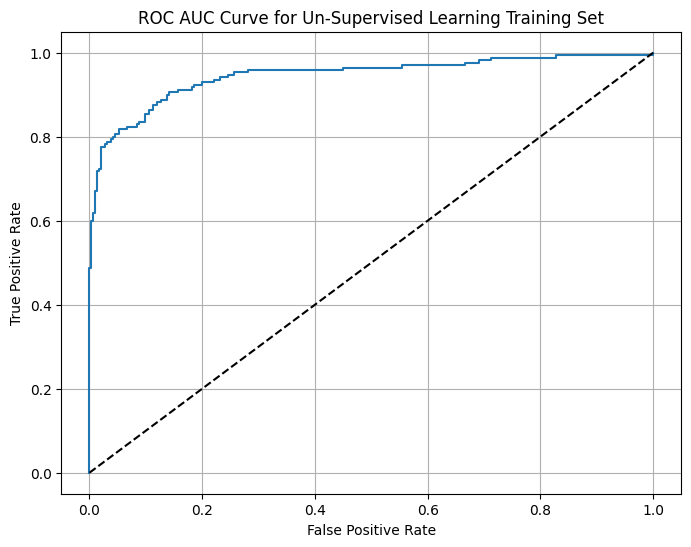


 Un-Supervised Testing auc: 98.545
Plotting ROC_AUC Curve


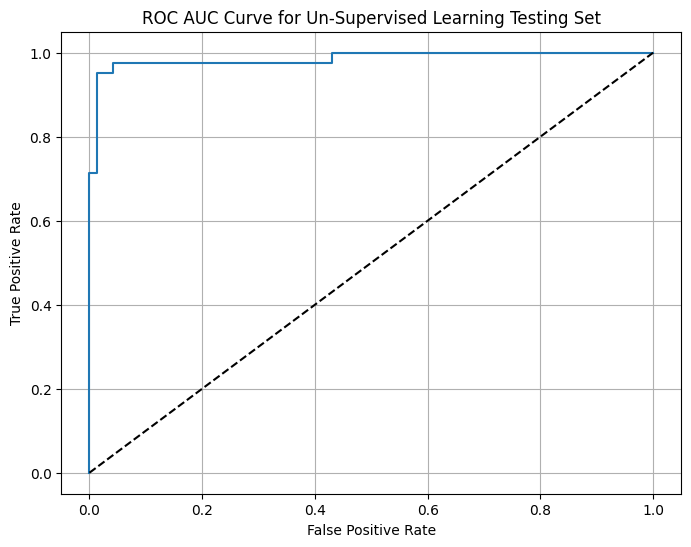

In [49]:
print("\n Plots for Max Accuracy over 'M' iterations for UnSupervised Learning")
un_idx = un_supervised_roc_auc_df.groupby('split')['roc_auc'].idxmax()
un_best_roc_auc_results = un_supervised_roc_auc_df.loc[un_idx, ['split', 'roc_auc', 'fpr', 'tpr']]

un_sup_train_auc = un_best_roc_auc_results.query("split == 'train'").iloc[0]['roc_auc']
print(f"\n Un-Supervised Training auc: {(un_sup_train_auc * 100):.3f}")
plot_roc_auc(un_best_roc_auc_results.query("split == 'train'").iloc[0]['fpr'], 
             un_best_roc_auc_results.query("split == 'train'").iloc[0]['tpr'], 
             un_sup_train_auc, 
             title="ROC AUC Curve for Un-Supervised Learning Training Set")

un_sup_test_auc = un_best_roc_auc_results.query("split == 'test'").iloc[0]['roc_auc']
print(f"\n Un-Supervised Testing auc: {(un_sup_test_auc * 100):.3f}")
plot_roc_auc(un_best_roc_auc_results.query("split == 'test'").iloc[0]['fpr'], 
             un_best_roc_auc_results.query("split == 'test'").iloc[0]['tpr'], 
             un_sup_test_auc, 
             title="ROC AUC Curve for Un-Supervised Learning Testing Set")



 Confusion Matrices with best accuracies from the M=30 iterations for unsupervised learning

 UnSupervised Learning Confusion Matrix Training Set


<Figure size 800x600 with 0 Axes>

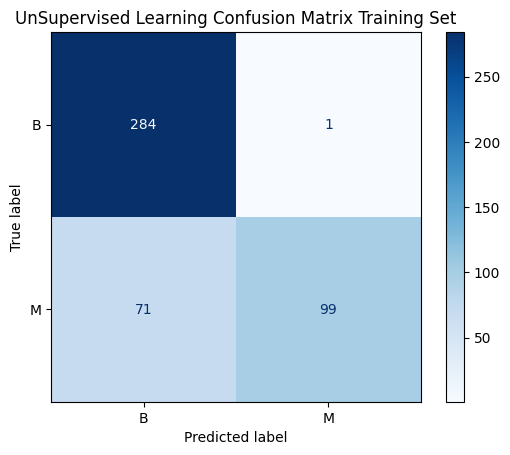


 UnSupervised Learning Confusion Matrix Testing Set


<Figure size 800x600 with 0 Axes>

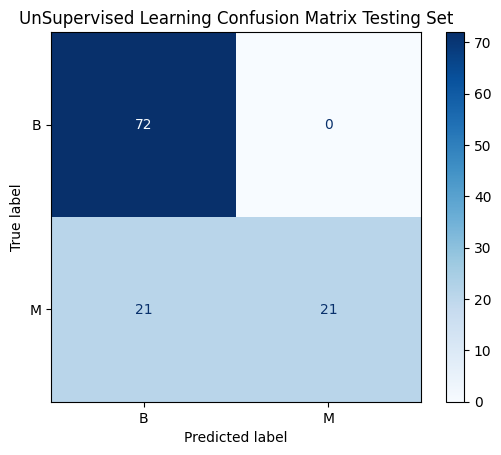

In [53]:
print("\n Confusion Matrices with best accuracies from the M=30 iterations for unsupervised learning")
for row in un_supervised_cm_df.itertuples():
    un_supervised_cm_df['accuracy'] = (row.tp + row.tn) / (row.tp + row.tn + row.fp + row.fn)
un_supervised_cm_df.head()

train_un_supervised_cm = un_supervised_cm_df.query("split == 'train'").sort_values("accuracy", ascending=False).iloc[0]
test_un_supervised_cm = un_supervised_cm_df.query("split == 'test'").sort_values("accuracy", ascending=False).iloc[0]
plot_conf_mtr(train_un_supervised_cm['tn'], train_un_supervised_cm['fp'], 
              train_un_supervised_cm['fn'], train_un_supervised_cm['tp'],
              title='UnSupervised Learning Confusion Matrix Training Set', classes=['B', 'M'])

plot_conf_mtr(test_un_supervised_cm['tn'], test_un_supervised_cm['fp'], 
              test_un_supervised_cm['fn'], test_un_supervised_cm['tp'],
              title='UnSupervised Learning Confusion Matrix Testing Set', classes=['B', 'M'])

#### (iv) Spectral Clustering

In [102]:
def spectral_clustering(X:pd.DataFrame, Y:pd.DataFrame, classes=[]):
    try:
        if X is None or Y is None:
            return []
        res_dict = {}
        for M in range(30):
            X_train, X_test, y_train, y_test = data_splitter(X, Y, classes=classes)
            sc = SpectralClustering(n_clusters=2, 
                                    affinity='rbf', 
                                    n_init=20,
                                    random_state=random.randint(0, 100))
            scaler = StandardScaler()
            
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            sc.fit(X_train_scaled)
            labels_train = sc.labels_
            cluster_0 = y_train[labels_train == 0]
            cluster_1 = y_train[labels_train == 1]
            label_0 = cluster_0.value_counts().idxmax()
            label_1 = cluster_1.value_counts().idxmax()
            cluster_map = {0: label_0, 1: label_1}
            labels_test = sc.fit_predict(X_test_scaled)

            y_pred_train = pd.Series(labels_train).map(cluster_map)
            y_pred_test = pd.Series(labels_test).map(cluster_map)

            train_similarity = rbf_kernel(X_train_scaled, X_train_scaled, gamma=1)
            cluster_0_idx = np.where(labels_train == 0)[0]
            cluster_1_idx = np.where(labels_train == 1)[0]
            
            train_sim_0 = train_similarity[:, cluster_0_idx].mean(axis=1)
            train_sim_1 = train_similarity[:, cluster_1_idx].mean(axis=1)
            
            if cluster_map[1] == 1:
                y_probs_train = train_sim_1 - train_sim_0
            else:
                y_probs_train = train_sim_0 - train_sim_1

            test_similarity = rbf_kernel(X_test_scaled, X_train_scaled, gamma=1)
            test_cluster_0_idx = np.where(labels_test == 0)[0]
            test_cluster_1_idx = np.where(labels_test == 1)[0]
            
            test_sim_0 = test_similarity[:, test_cluster_0_idx].mean(axis=1)
            test_sim_1 = test_similarity[:, test_cluster_1_idx].mean(axis=1)
            
            if cluster_map[1] == 1:
                y_probs = test_sim_1 - test_sim_0
            else:
                y_probs = test_sim_0 - test_sim_1
            # We have y_test, y_train, y_pred_test and y_pred_train
            # Now Calling metrics functions like previous iterations
                
            result = disp_classification_report(y_test, y_pred_test)
            result_train = disp_classification_report(y_train, y_pred_train)
                    
            fpr, tpr, thresh, roc_auc = calc_roc_auc(y_test, y_probs)
            fpr_, tpr_, thresh_, roc_auc_train = calc_roc_auc(y_train, y_probs_train)
                    
            cm = confusion_matrix(y_test, y_pred_test)
            cm_train = confusion_matrix(y_train, y_pred_train)
                    
            res_dict[M] = {
                "test": {
                    "roc_auc": roc_auc,
                    "fpr": fpr,
                    "tpr": tpr,
                    "confusion_matrix": cm,
                    "classification_report": result
                },
                "train": {
                    "roc_auc": roc_auc_train,
                    "fpr": fpr_,
                    "tpr": tpr_,
                    "confusion_matrix": cm_train,
                    "classification_report": result_train
                },
            }

        return res_dict
            
    except Exception as e:
        print(f"\n An error ocuured while running the spectral cluster pipeline: {e}")
        return {}

In [103]:
sc_res_dict = spectral_clustering(X, Y)
print("\n Classification Report and Associated Metrics for Spectral Clustering")
sc_roc_auc_df, sc_cm_df, sc_class_df = build_reports_dfs(sc_res_dict)
print("\n ROC AUC for Spectral Clustering (Train & Test)")
display(sc_roc_auc_df.head(10))
print("\n Confusion Matrix for Spectral Clustering (Train & Test)")
display(sc_cm_df.head(10))
print("\n Classification Report for Spectral Clustering (Train & Test)")
display(sc_class_df.head(10))


 Classification Report and Associated Metrics for Spectral Clustering

 ROC AUC for Spectral Clustering (Train & Test)


,iteration,split,roc_auc,fpr,tpr,accuracy
0,0,train,0.228968,"[0.0, 0.0035087719298245615, 0.129824561403508...","[0.0, 0.0, 0.0, 0.0058823529411764705, 0.00588...",0.626374
1,0,test,0.180886,"[0.0, 0.013888888888888888, 0.1388888888888889...","[0.0, 0.0, 0.0, 0.023809523809523808, 0.023809...",0.631579
2,1,train,0.764345,"[0.0, 0.0, 0.010526315789473684, 0.01052631578...","[0.0, 0.0058823529411764705, 0.047058823529411...",0.628571
3,1,test,0.794974,"[0.0, 0.013888888888888888, 0.0138888888888888...","[0.0, 0.0, 0.023809523809523808, 0.02380952380...",0.640351
4,2,train,0.214283,"[0.0, 0.0035087719298245615, 0.224561403508771...","[0.0, 0.0, 0.0, 0.0058823529411764705, 0.00588...",0.626374
5,2,test,0.524471,"[0.0, 0.0, 0.05555555555555555, 0.055555555555...","[0.0, 0.023809523809523808, 0.0238095238095238...",0.631579
6,3,train,0.771703,"[0.0, 0.0, 0.007017543859649123, 0.00701754385...","[0.0, 0.0058823529411764705, 0.047058823529411...",0.628571
7,3,test,0.792989,"[0.0, 0.0, 0.0, 0.013888888888888888, 0.013888...","[0.0, 0.023809523809523808, 0.0476190476190476...",0.640351
8,4,train,0.783911,"[0.0, 0.0, 0.0035087719298245615, 0.0035087719...","[0.0, 0.0058823529411764705, 0.035294117647058...",0.628571
9,4,test,0.658399,"[0.0, 0.013888888888888888, 0.1111111111111111...","[0.0, 0.0, 0.0, 0.047619047619047616, 0.047619...",0.640351



 Confusion Matrix for Spectral Clustering (Train & Test)


,iteration,split,tn,fp,fn,tp
0,0,train,285,0,170,0
1,0,test,72,0,42,0
2,1,train,285,0,169,1
3,1,test,72,0,41,1
4,2,train,285,0,170,0
5,2,test,72,0,42,0
6,3,train,285,0,169,1
7,3,test,72,0,41,1
8,4,train,285,0,169,1
9,4,test,72,0,41,1



 Classification Report for Spectral Clustering (Train & Test)


,iteration,split,class,precision,recall,f1-score,support
0,0,train,B,0.626374,1.000000,0.770270,285.0
1,0,train,M,0.000000,0.000000,0.000000,170.0
2,0,test,B,0.631579,1.000000,0.774194,72.0
3,0,test,M,0.000000,0.000000,0.000000,42.0
4,1,train,B,0.627753,1.000000,0.771313,285.0
5,1,train,M,1.000000,0.005882,0.011696,170.0
6,1,test,B,0.637168,1.000000,0.778378,72.0
7,1,test,M,1.000000,0.023810,0.046512,42.0
8,2,train,B,0.626374,1.000000,0.770270,285.0
9,2,train,M,0.000000,0.000000,0.000000,170.0


In [106]:
print("\n Average results over 'M' iterations for 'Spectral Clustering'")
display(sc_roc_auc_df.groupby('split', as_index=False).agg({
    'roc_auc': 'mean',
    'accuracy': 'mean'
}))
display(sc_cm_df.groupby('split').mean())
display(sc_class_df.groupby(['split', 'class']).mean())


 Average results over 'M' iterations for 'Spectral Clustering'


,split,roc_auc,accuracy
0,test,0.673104,0.633626
1,train,0.701420,0.628938


,iteration,tn,fp,fn,tp
split,,,,,
test,14.5,71.5,0.5,41.266667,0.733333
train,14.5,285.0,0.0,168.833333,1.166667


iteration  precision    recall  f1-score  support
split class                                                   
test  B           14.5   0.634075  0.993056  0.773943     72.0
      M           14.5   0.566667  0.017460  0.033140     42.0
train B           14.5   0.627985  1.000000  0.771487    285.0
      M           14.5   0.866667  0.006863  0.013604    170.0

In [113]:
print("\n Max results over 'M' iterations for 'Spectral Clustering'")
idx_sc = sc_roc_auc_df.groupby('split')['roc_auc'].idxmax()
sc_best_results = sc_roc_auc_df.loc[idx, ['iteration', 'split', 'roc_auc', 'accuracy']]
display(sc_best_results)


 Max results over 'M' iterations for 'Spectral Clustering'


,iteration,split,roc_auc,accuracy
43,21,test,0.850529,0.640351
10,5,train,0.798906,0.628571



 Plots for Max Accuracy over 'M' iterations for Spectral Clustering
Plotting ROC_AUC Curve


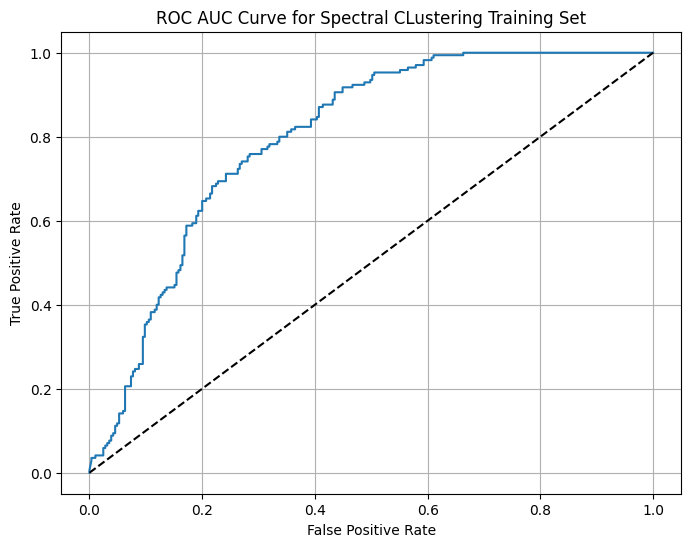

Plotting ROC_AUC Curve


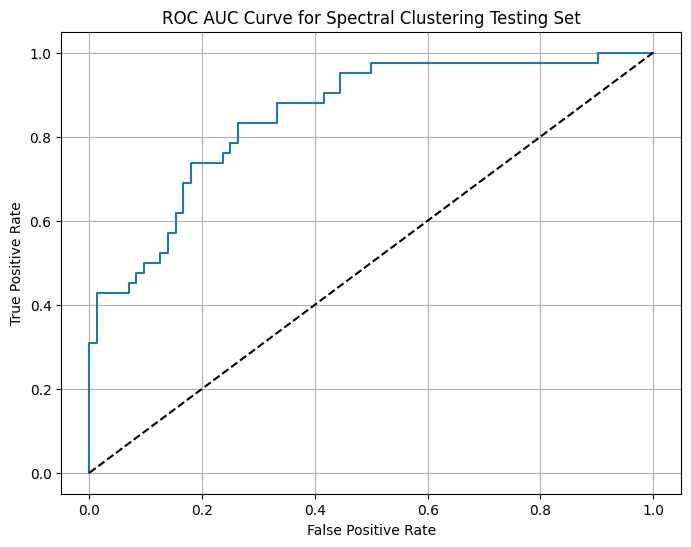

In [114]:
print("\n Plots for Max Accuracy over 'M' iterations for Spectral Clustering")
sc_best_roc_auc_results = sc_roc_auc_df.loc[idx_sc, ['split', 'roc_auc', 'fpr', 'tpr']]

plot_roc_auc(sc_best_roc_auc_results.query("split == 'train'").iloc[0]['fpr'], 
             sc_best_roc_auc_results.query("split == 'train'").iloc[0]['tpr'], 
             sc_best_roc_auc_results.query("split == 'train'").iloc[0]['roc_auc'], 
             title="ROC AUC Curve for Spectral CLustering Training Set")

plot_roc_auc(sc_best_roc_auc_results.query("split == 'test'").iloc[0]['fpr'], 
             sc_best_roc_auc_results.query("split == 'test'").iloc[0]['tpr'], 
             sc_best_roc_auc_results.query("split == 'test'").iloc[0]['roc_auc'], 
             title="ROC AUC Curve for Spectral Clustering Testing Set")


 Confusion Matrices with best accuracies from the M=30 iterations

 Spectral CLustering Confusion Matrix Training Set


<Figure size 800x600 with 0 Axes>

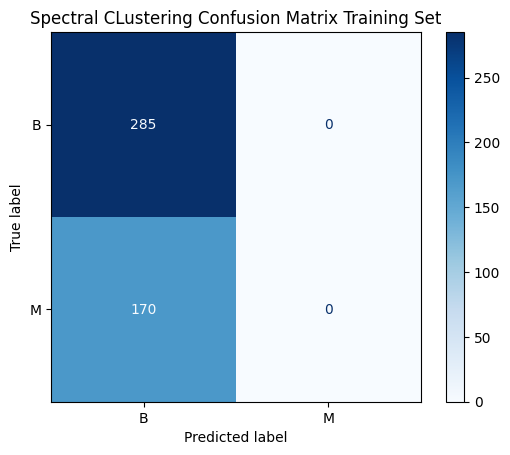


 Spectral Clustering Confusion Matrix Testing Set


<Figure size 800x600 with 0 Axes>

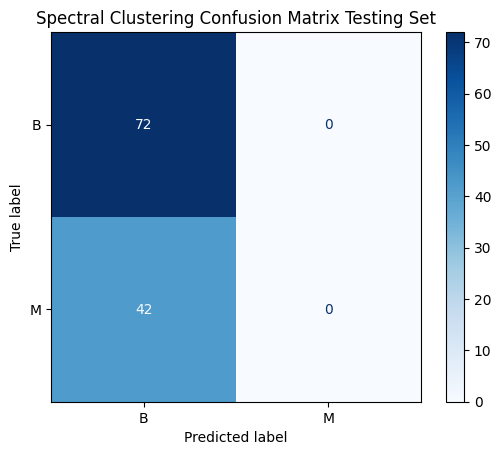

In [116]:
print("\n Confusion Matrices with best accuracies from the M=30 iterations")
for row in sc_cm_df.itertuples():
    sc_cm_df['accuracy'] = (row.tp + row.tn) / (row.tp + row.tn + row.fp + row.fn)
sc_cm_df.head()

train_sc_cm = sc_cm_df.query("split == 'train'").sort_values("accuracy", ascending=False).iloc[0]
test_sc_cm = sc_cm_df.query("split == 'test'").sort_values("accuracy", ascending=False).iloc[0]
plot_conf_mtr(train_sc_cm['tn'], train_sc_cm['fp'], 
              train_sc_cm['fn'], train_sc_cm['tp'],
              title='Spectral CLustering Confusion Matrix Training Set', classes=['B', 'M'])

plot_conf_mtr(test_sc_cm['tn'], test_sc_cm['fp'], 
              test_sc_cm['fn'], test_sc_cm['tp'],
              title='Spectral Clustering Confusion Matrix Testing Set', classes=['B', 'M'])

#### (v) Compare

<div>
<p>
Supervised learning achieves the best performance across all evaluation metrics, with the highest ROC AUC and accuracy on both training and test sets. This is expected, as it utilizes fully labeled data and learns a discriminative boundary directly.
</p>
<table border="1">
  <thead>
    <tr>
      <th colspan="6">Average over 'M' iterations for 'Supervised Learning'</th>
    </tr>
    <tr>
      <th>Split</th>
      <th>ROC AUC</th>
      <th>Accuracy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>0.994720</td>
      <td>0.977778</td>
    </tr>
    <tr>
      <td>train</td>
      <td>0.996966</td>
      <td>0.985421</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split</th>
      <th>TN</th>
      <th>FP</th>
      <th>FN</th>
      <th>TP</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>71.300000</td>
      <td>0.700000</td>
      <td>1.833333</td>
      <td>40.166667</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train</td>
      <td>283.666667</td>
      <td>1.333333</td>
      <td>5.300000</td>
      <td>164.700000</td>
      <td>14.5</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split / Class</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-Score</th>
      <th>Support</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test (B)</td>
      <td>0.975336</td>
      <td>0.990278</td>
      <td>0.982608</td>
      <td>72.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>test (M)</td>
      <td>0.983346</td>
      <td>0.956349</td>
      <td>0.969208</td>
      <td>42.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (B)</td>
      <td>0.981671</td>
      <td>0.995322</td>
      <td>0.988445</td>
      <td>285.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (M)</td>
      <td>0.991989</td>
      <td>0.968824</td>
      <td>0.980255</td>
      <td>170.0</td>
      <td>14.5</td>
    </tr>
  </tbody>
</table>
</div>

<div>
<p>
Semi-supervised learning performs comparably to supervised learning but does not consistently outperform it. While it achieves slightly higher training performance, this is likely due to the incorporation of pseudo-labeled data, which may lead to mild overfitting. On test data, supervised learning remains superior.
</p>
<table border="1">
  <thead>
    <tr>
      <th colspan="6">Average over 'M' iterations for 'Semi-Supervised Learning'</th>
    </tr>
    <tr>
      <th>Split</th>
      <th>ROC AUC</th>
      <th>Accuracy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>0.992703</td>
      <td>0.965205</td>
    </tr>
    <tr>
      <td>train</td>
      <td>0.998395</td>
      <td>0.987665</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split</th>
      <th>TN</th>
      <th>FP</th>
      <th>FN</th>
      <th>TP</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>70.533333</td>
      <td>1.466667</td>
      <td>2.500000</td>
      <td>39.500000</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train</td>
      <td>141.566667</td>
      <td>0.433333</td>
      <td>2.366667</td>
      <td>82.633333</td>
      <td>14.5</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split / Class</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-Score</th>
      <th>Support</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test (B)</td>
      <td>0.966281</td>
      <td>0.979630</td>
      <td>0.972616</td>
      <td>72.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>test (M)</td>
      <td>0.965940</td>
      <td>0.940476</td>
      <td>0.952172</td>
      <td>42.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (B)</td>
      <td>0.983677</td>
      <td>0.996948</td>
      <td>0.990239</td>
      <td>142.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (M)</td>
      <td>0.994774</td>
      <td>0.972157</td>
      <td>0.983247</td>
      <td>85.0</td>
      <td>14.5</td>
    </tr>
  </tbody>
</table>
</div>

<div>
<p>
Unsupervised learning using K-means clustering performs moderately well despite not using labels during training. It is able to capture some structure in the data, but its performance is significantly lower than supervised approaches, as expected.
</p>
<table border="1">
  <thead>
    <tr>
      <th colspan="6">Average over 'M' iterations for 'Unsupervised Learning'</th>
    </tr>
    <tr>
      <th>Split</th>
      <th>ROC AUC</th>
      <th>Accuracy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>0.939848</td>
      <td>0.852924</td>
    </tr>
    <tr>
      <td>train</td>
      <td>0.933975</td>
      <td>0.851648</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split</th>
      <th>TN</th>
      <th>FP</th>
      <th>FN</th>
      <th>TP</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>71.900000</td>
      <td>0.100000</td>
      <td>16.666667</td>
      <td>25.333333</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train</td>
      <td>284.100000</td>
      <td>0.900000</td>
      <td>66.600000</td>
      <td>103.400000</td>
      <td>14.5</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split / Class</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-Score</th>
      <th>Support</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test (B)</td>
      <td>0.813008</td>
      <td>0.998611</td>
      <td>0.895971</td>
      <td>72.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>test (M)</td>
      <td>0.996327</td>
      <td>0.603175</td>
      <td>0.748207</td>
      <td>42.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (B)</td>
      <td>0.810189</td>
      <td>0.996842</td>
      <td>0.893849</td>
      <td>285.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (M)</td>
      <td>0.991382</td>
      <td>0.608235</td>
      <td>0.753681</td>
      <td>170.0</td>
      <td>14.5</td>
    </tr>
  </tbody>
</table>
</div>

<div>
<p>
Spectral clustering performs the worst among all methods. It frequently collapses to a single cluster and fails to properly separate the classes, resulting in very low recall for the malignant class. This poor performance is likely due to sensitivity to kernel parameters and the nature of the dataset, which appears to be more suitable for linear separation rather than graph-based clustering.
</p>
<table border="1">
  <thead>
    <tr>
      <th colspan="6">Average over 'M' iterations for 'Spectral Clustering'</th>
    </tr>
    <tr>
      <th>Split</th>
      <th>ROC AUC</th>
      <th>Accuracy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>0.673104</td>
      <td>0.633626</td>
    </tr>
    <tr>
      <td>train</td>
      <td>0.701420</td>
      <td>0.628938</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split</th>
      <th>TN</th>
      <th>FP</th>
      <th>FN</th>
      <th>TP</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test</td>
      <td>71.500000</td>
      <td>0.500000</td>
      <td>41.266667</td>
      <td>0.733333</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train</td>
      <td>285.000000</td>
      <td>0.000000</td>
      <td>168.833333</td>
      <td>1.166667</td>
      <td>14.5</td>
    </tr>
  </tbody>
  <thead>
    <tr>
      <th>Split / Class</th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1-Score</th>
      <th>Support</th>
      <th>Iteration Avg</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>test (B)</td>
      <td>0.634075</td>
      <td>0.993056</td>
      <td>0.773943</td>
      <td>72.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>test (M)</td>
      <td>0.566667</td>
      <td>0.017460</td>
      <td>0.033140</td>
      <td>42.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (B)</td>
      <td>0.627985</td>
      <td>1.000000</td>
      <td>0.771487</td>
      <td>285.0</td>
      <td>14.5</td>
    </tr>
    <tr>
      <td>train (M)</td>
      <td>0.866667</td>
      <td>0.006863</td>
      <td>0.013604</td>
      <td>170.0</td>
      <td>14.5</td>
    </tr>
  </tbody>
</table>
</div>
<div>
Overall, the results align with expectations: supervised learning performs best, followed by semi-supervised learning, with unsupervised methods performing worse in comparison.
</div>

## 2. Active Learning Using Support Vector Machines

### (a) Download the banknote authentication Data Set

In [144]:
DATA_PATH = Path("../data/data_banknote_authentication.txt")
bank_df = pd.DataFrame()
if os.path.exists(DATA_PATH):
    bank_df = pd.read_csv(DATA_PATH, header=None)
print(f"\n Binary Prediction: \n {bank_df[4].unique()}")
display(bank_df.head(5))


 Binary Prediction: 
 [0 1]


,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


### (b) Repeat each of the following two procedures 50 times

#### (i) Passive

In [162]:
def run_passive(bank_df:pd.DataFrame) -> pd.DataFrame:
    res = []
    try:
        if bank_df is None:
            return []
        for i in range(50):
            n = 472
            test_df = bank_df.sample(n=n, random_state=None)
            train_df = bank_df.drop(test_df.index)
            X_test = test_df.drop([4], axis=1)
            y_test = test_df[4]

            train_df = train_df.sample(frac=1).reset_index(drop=True)
            
            params = {'svm__C': [0.01, 0.1, 1, 10, 100]}
            err = []

            for size in range(10, len(train_df)+1, 10):
                subset = train_df.iloc[:size]
                X_sub = subset.drop([4], axis=1)
                y_sub = subset[4]

                if len(y_sub.unique()) < 2:
                    continue
                
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('svm', LinearSVC(penalty='l1', dual=False, max_iter=100000))])
                 
                grid_search = GridSearchCV(pipeline, 
                                            params, 
                                            cv=5, 
                                            scoring='accuracy', 
                                            n_jobs=-1)
                
                grid_search.fit(X_sub, y_sub)
                 
                y_pred = grid_search.predict(X_test)
                err.append(1 - (accuracy_score(y_test, y_pred)))
                
            res.append(err)
            
        return pd.DataFrame(res)
        
    except Exception as e:
        print(f"\n An error ocuured running the passive learning pipeline: {e}")

In [156]:
passive_df = run_passive(bank_df)
display(passive_df.describe())

C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.

,0,1,2,3,4,5,6,7,8,9,...,80,81,82,83,84,85,86,87,88,89
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.165466,0.065932,0.037458,0.034873,0.030975,0.031483,0.027881,0.026144,0.025424,0.024492,...,0.009915,0.009915,0.010297,0.010042,0.010042,0.010000,0.010042,0.010042,0.010169,0.010212
std,0.121607,0.052743,0.026971,0.026820,0.017110,0.018336,0.010966,0.014682,0.015145,0.013442,...,0.003767,0.003618,0.003398,0.003419,0.003392,0.003531,0.003652,0.003551,0.003555,0.003674
min,0.021186,0.016949,0.010593,0.010593,0.010593,0.008475,0.008475,0.008475,0.006356,0.006356,...,0.002119,0.002119,0.002119,0.002119,0.002119,0.002119,0.002119,0.002119,0.002119,0.002119
25%,0.071504,0.023305,0.023835,0.023305,0.023835,0.021186,0.021186,0.019068,0.016949,0.015360,...,0.008475,0.008475,0.008475,0.008475,0.008475,0.008475,0.008475,0.008475,0.008475,0.008475
50%,0.156780,0.034958,0.029661,0.027542,0.027542,0.027542,0.027542,0.023305,0.022246,0.023305,...,0.008475,0.008475,0.010593,0.009534,0.010593,0.010593,0.008475,0.008475,0.009534,0.009534
75%,0.178496,0.120233,0.040254,0.033898,0.033369,0.035487,0.031780,0.031250,0.029661,0.031250,...,0.012712,0.012712,0.012712,0.012712,0.012712,0.012712,0.012712,0.012712,0.012712,0.012712
max,0.463983,0.184322,0.158898,0.163136,0.131356,0.127119,0.059322,0.108051,0.101695,0.086864,...,0.019068,0.016949,0.016949,0.016949,0.016949,0.016949,0.016949,0.016949,0.016949,0.019068


In [159]:
passive_df_res = pd.DataFrame({"SVM": range(1, 91), 
                               "Size": list(range(10, 910, 10)), 
                               "Avg_err": passive_df.mean()})
passive_df_res

,SVM,Size,Avg_err
0,1,10,0.165466
1,2,20,0.065932
2,3,30,0.037458
3,4,40,0.034873
4,5,50,0.030975
...,...,...,...
85,86,860,0.010000
86,87,870,0.010042
87,88,880,0.010042
88,89,890,0.010169


#### (ii) Active

In [167]:
def run_active(bank_df: pd.DataFrame = []) -> pd.DataFrame:
    try:
        if bank_df is None:
            return []
        res = []
        for i in range(50):
            n =472
            test_df = bank_df.sample(n=n, random_state=None)
            train_df = bank_df.drop(test_df.index)
            X_test = test_df.drop([4], axis=1)
            y_test = test_df[4]

            train_df = train_df.sample(frac=1).reset_index(drop=True)
            
            params = {'svm__C': [0.01, 0.1, 1, 10, 100]}
            labeled = train_df.iloc[:10].copy()
            pool = train_df.iloc[10:].copy()
            err = []

            while len(labeled) <= len(train_df):

                X_lab = labeled.drop([4], axis=1)
                y_lab = labeled[4]

                if len(y_lab.unique()) < 2:
                    break
                    
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('svm', LinearSVC(penalty='l1', dual=False, max_iter=100000))])
                 
                grid_search = GridSearchCV(pipeline, 
                                            params, 
                                            cv=5, 
                                            scoring='accuracy', 
                                            n_jobs=-1)
                
                grid_search.fit(X_lab, y_lab)
            
                y_pred = grid_search.predict(X_test)
                error = 1 - accuracy_score(y_test, y_pred)
                err.append(error)
                
                if len(pool) == 0:
                    break

                X_pool = pool.drop([4], axis=1)
                scores = np.abs(grid_search.decision_function(X_pool))

                idx = np.argsort(scores)[:10]
                new_pts = pool.iloc[idx]
            
                labeled = pd.concat([labeled, new_pts])
                pool = pool.drop(pool.index[idx])
            res.append(err)
        
        return pd.DataFrame(res) 
            
    except Exception as e:
        print(f"An error occured in running the active learning pipeline: {e}")
        return []

In [168]:
active_df = run_active(bank_df)
active_df_res = pd.DataFrame({"SVM": range(1, 91), 
                               "Size": list(range(10, 910, 10)), 
                               "Avg_err": active_df.mean()})
active_df_res

C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_valida

,SVM,Size,Avg_err
0,1,10,0.188220
1,2,20,0.057881
2,3,30,0.043475
3,4,40,0.021610
4,5,50,0.017331
...,...,...,...
85,86,860,0.011610
86,87,870,0.011398
87,88,880,0.011441
88,89,890,0.011610


### (c) Average the 50 test errors

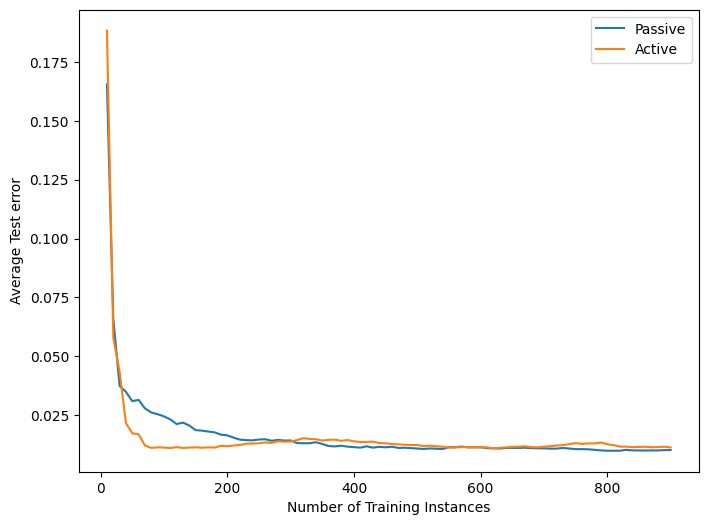

In [169]:
plt.figure(figsize=(8, 6))
passive_plt = plt.plot(passive_df_res["Size"], passive_df_res["Avg_err"],label='Passive')
active_plt = plt.plot(active_df_res["Size"], active_df_res["Avg_err"],label='Active')
plt.legend()
plt.ylabel('Average Test error')
plt.xlabel('Number of Training Instances')
plt.show()

<div>
<p>
One can observe that Active learning has a steeper curve as comapred to passive learning. This means that, active learning reached minimum error earlier than passive learning. 
</p>
</div>